# COMPAS one-parameter comparison
**Author: Maryam Ahsan**

> **NOTE:** The work in this noteboook was inspired while working through [`tutorial_1_introduction_to_population_synthesis.ipynb`](https://github.com/FloorBroekgaarden/GROWL-catalog-public/blob/main/onboarding_growl/tutorial_1_introduction_to_population_synthesis.ipynb) as part of GROWL onboarding, which is why some blocks of code and conventions/asssumptions used here will be similar to the ones in tutorial 1.That is the notebook to be studied to understand the physics and working done here.

>AI was used to help write the code in [Section 2](#2-Reusable-loading-and-validation-functions) and [Section 3](#3-Detect-events-and-summarize-outcomes).

This notebook compares a **standard [COMPAS](https://gwlandscape.org.au/single-binary-form/) detailed-output run** with every `.h5` file in one experiment folder. It is designed for controlled experiments: one initial parameter changes while the remaining initial conditions stay fixed.

This executed run is for initial separation, but the loading, validation, summary, event-detection, and plotting functions can be reused for metallicity, masses, mass ratio or eccentricity.

## Folder arrangement

```text
data/
├── BSE_Detailed_Output_Standard.h5
└── separation_experiment/
    ├── run_1.h5
    ├── run_2.h5
    └── ...
```

## Standard Run Parameters

Basically the pre-set COMPAS simulation parameters.

| Field | Value |
|---|---|
| Mass 1 | `35` |
| Mass 2 | `31` |
| Metallicity | `0.001` |
| Eccentricity | `0` |
| Separation | `3.5` |
| Orbital Period | *(leave blank)* |

Only edit the configuration cell below when switching experiments. Filenames do not need to contain parameter values: values are read directly from each HDF5 file.

In [15]:
from pathlib import Path
import warnings
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

In [16]:
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linestyle": ":",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

# COMPAS stellar type codes
STELLAR_TYPES = {
    0:  "MS (<= 0.7 Msun)",
    1:  "Main sequence",
    2:  "Hertzsprung gap",
    3:  "First giant branch",
    4:  "Core helium burning",
    5:  "Early AGB",
    6:  "Thermally pulsing AGB",
    7:  "Naked helium star MS",
    8:  "Naked helium star HG",
    9:  "Naked helium star GB",
    10: "Helium white dwarf",
    11: "Carbon-oxygen white dwarf",
    12: "Oxygen-neon white dwarf",
    13: "Neutron star",
    14: "Black hole",
    15: "Massless remnant",
    16: "Chemically homogeneous"
}

# COMPAS mass transfer history codes
MT_HISTORY = {
    0:"No mass transfer",
    1:"Stable MT 1→2",
    2:"Stable MT 2→1",
    3:"CE 1→2 (survived)",
    4:"CE 2→1 (survived)",
    5:"Double-core CE (survived)",
    6:"Merger"
}

AU_IN_RSUN = 215.032

C1, C2, CSYS = "#C1272D", "#0B5FA5", "#222222"

## 1. Configuration

For a new experiment, change only these paths and `VARIED_PARAMETER`. Supported names are listed in `PARAMETER_INFO` below.

In [17]:
STANDARD_FILE = Path("data/BSE_Detailed_Output_Standard.h5")
EXPERIMENT_FOLDER = Path("data/metallicity_variation")
VARIED_PARAMETER = "metallicity"

PARAMETER_INFO = {
    "initial_separation_au": ("Initial separation", "AU"),
    "initial_separation_rsun": ("Initial separation", r"R$_\odot$"),
    "metallicity": ("Metallicity", "Z"),
    "m1_zams": (r"Initial $M_1$", r"M$_\odot$"),
    "m2_zams": (r"Initial $M_2$", r"M$_\odot$"),
    "mass_ratio_zams": (r"Initial mass ratio $q=M_2/M_1$", ""),
    "eccentricity_zams": ("Initial eccentricity", "0"),
}

## 2. Reusable loading and validation functions

The loader reads all one-dimensional, timestep-length datasets, so most detailed-output columns remain available even if they are not used immediately. It also extracts initial conditions independently of filenames.

In [18]:
def _value_at_start(f, key, fallback=np.nan):
    if key not in f or len(f[key]) == 0:
        return fallback
    return np.asarray(f[key][0]).item()


def load_compas_file(path, is_standard=False):
    path = Path(path)
    with h5py.File(path, "r") as f:
        n = len(f["Time"])
        data = {}
        units = {}
        for key in f.keys():
            ds = f[key]
            if isinstance(ds, h5py.Dataset) and ds.ndim == 1 and len(ds) == n:
                data[key] = ds[()]
                unit = ds.attrs.get("units", "")
                units[key] = unit.decode() if isinstance(unit, bytes) else str(unit)
        df = pd.DataFrame(data)

        a0_rsun = float(_value_at_start(f, "SemiMajorAxis"))
        m1 = float(_value_at_start(f, "Mass@ZAMS(1)", _value_at_start(f, "Mass(1)")))
        m2 = float(_value_at_start(f, "Mass@ZAMS(2)", _value_at_start(f, "Mass(2)")))
        metadata = {
            "file": path.name,
            "path": path,
            "is_standard": bool(is_standard),
            "m1_zams": m1,
            "m2_zams": m2,
            "mass_ratio_zams": m2 / m1,
            "metallicity": float(_value_at_start(f, "Metallicity@ZAMS(1)")),
            "eccentricity_zams": float(_value_at_start(f, "Eccentricity")),
            "initial_separation_rsun": a0_rsun,
            "initial_separation_au": a0_rsun / AU_IN_RSUN,
            "n_timesteps": n,
        }
    return {"df": df, "meta": metadata, "units": units}


def load_experiment(standard_file, experiment_folder, varied_parameter):
    standard_file, experiment_folder = Path(standard_file), Path(experiment_folder)
    if not standard_file.exists():
        raise FileNotFoundError(f"Standard file not found: {standard_file.resolve()}")
    if not experiment_folder.exists():
        raise FileNotFoundError(f"Experiment folder not found: {experiment_folder.resolve()}")

    files = sorted(experiment_folder.glob("*.h5"))
    if not files:
        raise FileNotFoundError(f"No .h5 files found in {experiment_folder.resolve()}")
    if standard_file.resolve() in {p.resolve() for p in files}:
        raise ValueError("The standard file is also inside the experiment folder; remove the duplicate.")

    runs = [load_compas_file(standard_file, is_standard=True)]
    runs += [load_compas_file(p) for p in files]
    if varied_parameter not in runs[0]["meta"]:
        raise KeyError(f"Unknown varied parameter: {varied_parameter}")
    runs.sort(key=lambda run: run["meta"][varied_parameter])
    return runs


def initial_conditions_table(runs):
    cols = ["file", "is_standard", "m1_zams", "m2_zams", "mass_ratio_zams",
            "metallicity", "eccentricity_zams", "initial_separation_rsun",
            "initial_separation_au", "n_timesteps"]
    return pd.DataFrame([r["meta"] for r in runs])[cols]


def validate_controlled_experiment(runs, varied_parameter, rtol=1e-7, atol=1e-10):
    candidates = ["m1_zams", "m2_zams", "metallicity", "eccentricity_zams",
                  "initial_separation_rsun", "initial_separation_au"]
    linked = {
        "initial_separation_au": {"initial_separation_au", "initial_separation_rsun"},
        "initial_separation_rsun": {"initial_separation_au", "initial_separation_rsun"},
        "mass_ratio_zams": {"mass_ratio_zams", "m1_zams", "m2_zams"},
    }
    excluded = linked.get(varied_parameter, {varied_parameter})
    rows = []
    for key in candidates:
        values = np.array([r["meta"][key] for r in runs], dtype=float)
        expected_constant = key not in excluded
        constant = np.allclose(values, values[0], rtol=rtol, atol=atol, equal_nan=True)
        rows.append({"quantity": key, "expected": "constant" if expected_constant else "varied",
                     "constant_in_files": constant, "minimum": np.nanmin(values),
                     "maximum": np.nanmax(values),
                     "status": "PASS" if constant == expected_constant else "CHECK"})
    result = pd.DataFrame(rows)
    if (result.status == "CHECK").any():
        warnings.warn("The files may not form a one-parameter experiment. Inspect the validation table.")
    return result

In [19]:
runs = load_experiment(STANDARD_FILE, EXPERIMENT_FOLDER, VARIED_PARAMETER)
initial_conditions = initial_conditions_table(runs)
validation = validate_controlled_experiment(runs, VARIED_PARAMETER)

print(f"Loaded {len(runs)} simulations: one standard + {len(runs)-1} experiment files.\n")
display(initial_conditions.round({
    "m1_zams":2, "m2_zams":2, "mass_ratio_zams":3,
    "metallicity":5, "eccentricity_zams":3,
    "initial_separation_rsun":2, "initial_separation_au":2,
}))
display(validation)

Loaded 5 simulations: one standard + 4 experiment files.



,file,is_standard,m1_zams,m2_zams,mass_ratio_zams,metallicity,eccentricity_zams,initial_separation_rsun,initial_separation_au,n_timesteps
0,BSE_Detailed_Output_Standard.h5,True,35.0,31.0,0.886,0.001,0.0,752.61,3.5,3951
1,BSE_Detailed_Output_0.005.h5,False,35.0,31.0,0.886,0.005,0.0,752.61,3.5,5695
2,BSE_Detailed_Output_0.01.h5,False,35.0,31.0,0.886,0.010,0.0,752.61,3.5,1581
3,BSE_Detailed_Output_0.02.h5,False,35.0,31.0,0.886,0.020,0.0,752.61,3.5,7310
4,BSE_Detailed_Output_0.03.h5,False,35.0,31.0,0.886,0.030,0.0,752.61,3.5,9109


,quantity,expected,constant_in_files,minimum,maximum,status
0,m1_zams,constant,True,35.000000,35.000000,PASS
1,m2_zams,constant,True,31.000000,31.000000,PASS
2,metallicity,varied,False,0.001000,0.030000,PASS
3,eccentricity_zams,constant,True,0.000000,0.000000,PASS
4,initial_separation_rsun,constant,True,752.612545,752.612545,PASS
5,initial_separation_au,constant,True,3.500003,3.500003,PASS


## 3. Detect events and summarize outcomes

Event times are detected from each run. No separation, event time, mass-transfer direction, or common-envelope code is hard-coded.

In [20]:
def first_true_time(df, condition):
    idx = np.flatnonzero(np.asarray(condition, dtype=bool))
    return float(df["Time"].iloc[idx[0]]) if len(idx) else np.nan


def episode_starts(values, target=None):
    values = np.asarray(values)
    previous = np.r_[values[0], values[:-1]]
    changed = values != previous
    mask = changed & (values != 0)
    if target is not None:
        mask &= np.isin(values, target)
    return np.flatnonzero(mask)


def find_events(df):
    events = []
    time = df["Time"].to_numpy()
    for star in (1, 2):
        key = f"Stellar_Type({star})"
        if key in df:
            st = df[key].to_numpy(dtype=int)
            for i in np.flatnonzero(np.diff(st) != 0) + 1:
                events.append({"time_myr":time[i], "category":"stellar type",
                               "event":f"Star {star}: {STELLAR_TYPES.get(st[i-1], st[i-1])} → {STELLAR_TYPES.get(st[i], st[i])}"})
    if "MT_History" in df:
        mt = df["MT_History"].to_numpy(dtype=int)
        for i in episode_starts(mt):
            events.append({"time_myr":time[i], "category":"interaction",
                           "event":MT_HISTORY.get(mt[i], f"MT code {mt[i]}")})
    if "Unbound" in df:
        for i in np.flatnonzero(np.diff(df["Unbound"].astype(int)) > 0) + 1:
            events.append({"time_myr":time[i], "category":"disruption", "event":"Binary became unbound"})
    return pd.DataFrame(events).sort_values("time_myr").reset_index(drop=True) if events else pd.DataFrame(columns=["time_myr","category","event"])


G_SI, C_SI = 6.67430e-11, 2.99792458e8
MSUN, RSUN, GYR = 1.98892e30, 6.957e8, 3.15576e16

def merger_time_gyr(m1, m2, a_rsun, eccentricity=0.0):
    '''Peters circular time with the common eccentricity correction factor.'''
    if not all(np.isfinite([m1, m2, a_rsun, eccentricity])) or min(m1, m2, a_rsun) <= 0:
        return np.nan
    m1_si, m2_si, a_si = m1*MSUN, m2*MSUN, a_rsun*RSUN
    t_circ = (5/256) * C_SI**5 * a_si**4 / (G_SI**3*m1_si*m2_si*(m1_si+m2_si))
    e = np.clip(eccentricity, 0, 0.999999)
    correction = (1-e**2)**3.5 / (1 + 73*e**2/24 + 37*e**4/96)
    return t_circ * correction / GYR


def final_system_label(st1, st2, merger, unbound):
    if merger: return "Merger"
    pair = tuple(sorted((int(st1), int(st2))))
    labels = {(14,14):"BBH", (13,14):"BH–NS", (13,13):"BNS"}
    result = labels.get(pair, f"{STELLAR_TYPES.get(pair[0], pair[0])} + {STELLAR_TYPES.get(pair[1], pair[1])}")
    return result + (" (unbound)" if unbound else "")


def summarize_run(run, varied_parameter):
    df, meta = run["df"], run["meta"]
    mt = df["MT_History"].to_numpy(dtype=int) if "MT_History" in df else np.zeros(len(df), dtype=int)
    stable = np.isin(mt, [1,2])
    ce = np.isin(mt, [3,4,5])
    merger = np.any(mt == 6)
    rlof = np.zeros(len(df), dtype=bool)
    for star in (1,2):
        r, rl = f"Radius({star})", f"RocheLobe({star})"
        if r in df and rl in df:
            rlof |= (df[r].to_numpy() >= df[rl].to_numpy())
    st1, st2 = int(df["Stellar_Type(1)"].iloc[-1]), int(df["Stellar_Type(2)"].iloc[-1])
    unbound = bool(df["Unbound"].iloc[-1]) if "Unbound" in df else False
    m1f, m2f = float(df["Mass(1)"].iloc[-1]), float(df["Mass(2)"].iloc[-1])
    af, ef = float(df["SemiMajorAxis"].iloc[-1]), float(df["Eccentricity"].iloc[-1])
    is_dco = st1 in (13,14) and st2 in (13,14) and not merger and not unbound
    return {
        "parameter":meta[varied_parameter], "standard":meta["is_standard"], "file":meta["file"],
        "RLOF":bool(rlof.any()), "stable_MT":bool(stable.any()), "common_envelope":bool(ce.any()),
        "merger":bool(merger), "unbound":unbound,
        "first_RLOF_Myr":first_true_time(df, rlof), "first_stable_MT_Myr":first_true_time(df, stable),
        "first_CE_Myr":first_true_time(df, ce), "end_time_Myr":float(df["Time"].iloc[-1]),
        "final_type_1":STELLAR_TYPES.get(st1, str(st1)), "final_type_2":STELLAR_TYPES.get(st2, str(st2)),
        "final_system":final_system_label(st1, st2, merger, unbound),
        "final_mass_1":m1f, "final_mass_2":m2f, "final_separation_Rsun":af,
        "final_eccentricity":ef,
        "GW_merger_time_Gyr":merger_time_gyr(m1f,m2f,af,ef) if is_dco else np.nan,
    }


summary = pd.DataFrame([summarize_run(r, VARIED_PARAMETER) for r in runs]).sort_values("parameter").reset_index(drop=True)
summary

,parameter,standard,file,RLOF,stable_MT,common_envelope,merger,unbound,first_RLOF_Myr,first_stable_MT_Myr,first_CE_Myr,end_time_Myr,final_type_1,final_type_2,final_system,final_mass_1,final_mass_2,final_separation_Rsun,final_eccentricity,GW_merger_time_Gyr
0,0.001,True,BSE_Detailed_Output_Standard.h5,True,True,True,False,False,6.127565,6.127565,7.581993,7.891746,Black hole,Black hole,BBH,9.726285,11.543521,9.909014,0.079485,5.814525e-01
1,0.005,False,BSE_Detailed_Output_0.005.h5,True,True,False,False,False,5.827771,5.827771,NaN,7.901693,Black hole,Black hole,BBH,7.046070,15.058051,5609.902107,0.087447,6.029997e+10
2,0.010,False,BSE_Detailed_Output_0.01.h5,True,True,False,True,False,5.647893,5.647893,NaN,7.195108,Black hole,Hertzsprung gap,Merger,6.538053,12.613880,18.189015,0.000000,NaN
3,0.020,False,BSE_Detailed_Output_0.02.h5,True,True,True,False,False,5.328623,5.328623,7.137065,7.510521,Black hole,Black hole,BBH,3.829627,5.279223,6.956481,0.428893,5.958302e-01
4,0.030,False,BSE_Detailed_Output_0.03.h5,True,True,False,False,False,5.065719,5.065719,NaN,7.211650,Neutron star,Black hole,BH–NS,2.391002,15.257514,9624.786958,0.098534,1.877828e+12


## 4. Evolutionary-channel map

This table and figure show which interactions occur as the varied parameter changes. A blank cell means that event did not occur.

,RLOF,stable_MT,common_envelope,merger,unbound
parameter,,,,,
0.001,Yes,Yes,Yes,—,—
0.005,Yes,Yes,—,—,—
0.010,Yes,Yes,—,Yes,—
0.020,Yes,Yes,Yes,—,—
0.030,Yes,Yes,—,—,—


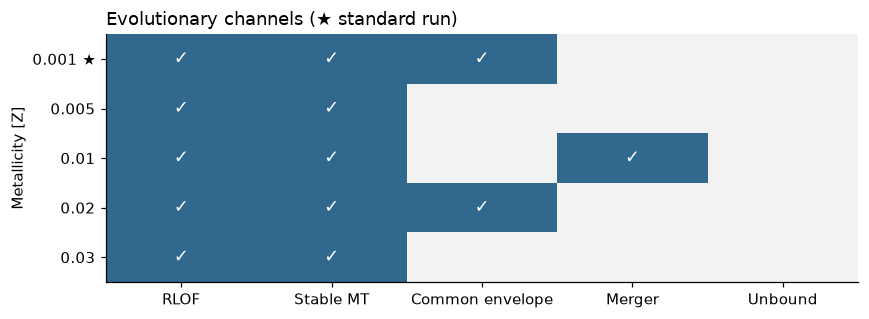

In [21]:
event_cols = ["RLOF", "stable_MT", "common_envelope", "merger", "unbound"]
channel_table = summary.set_index("parameter")[event_cols].replace({True:"Yes", False:"—"})
display(channel_table)

fig, ax = plt.subplots(figsize=(8, max(3, 0.55*len(summary))))
matrix = summary[event_cols].astype(int).to_numpy()
ax.imshow(matrix, aspect="auto", cmap=ListedColormap(["#F2F2F2", "#31688E"]), vmin=0, vmax=1)
ax.set_xticks(range(len(event_cols)), ["RLOF", "Stable MT", "Common envelope", "Merger", "Unbound"])
label, unit = PARAMETER_INFO[VARIED_PARAMETER]
yt = [f"{x:g}" + (" ★" if std else "") for x, std in zip(summary.parameter, summary.standard)]
ax.set_yticks(range(len(summary)), yt)
ax.set_ylabel(f"{label}" + (f" [{unit}]" if unit else ""))
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, "✓" if matrix[i,j] else "", ha="center", va="center", color="white", fontsize=12)
ax.grid(False)
ax.set_title("Evolutionary channels (★ standard run)", loc="left")
plt.tight_layout()
plt.show()

## 5. Final outcomes versus the varied parameter

The standard run is marked with a star. Gravitational-wave merger time is shown only for bound double compact objects.

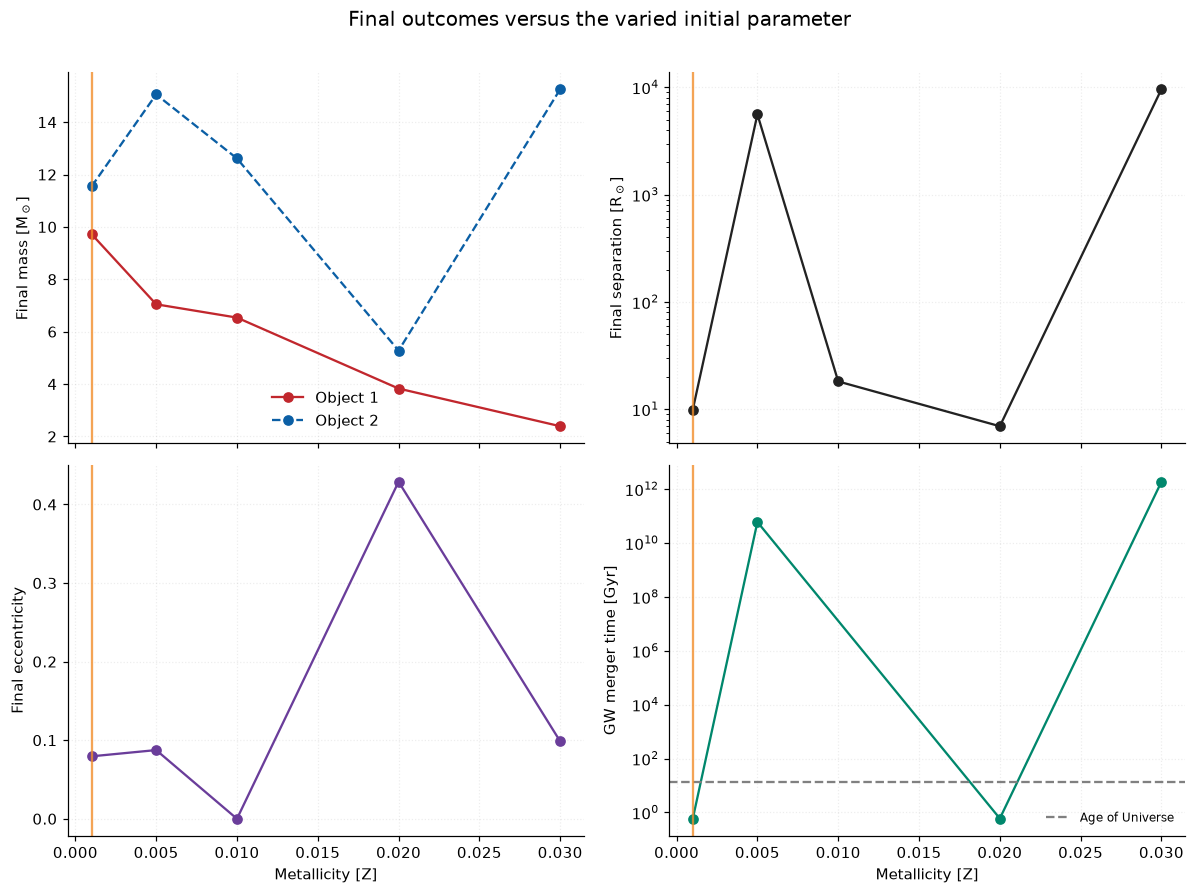

In [22]:
def plot_outcomes(summary, varied_parameter):
    x = summary["parameter"].to_numpy()
    std = summary["standard"].to_numpy(dtype=bool)
    label, unit = PARAMETER_INFO[varied_parameter]
    xlabel = label + (f" [{unit}]" if unit else "")
    fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)

    axes[0,0].plot(x, summary.final_mass_1, "o-", color=C1, label="Object 1")
    axes[0,0].plot(x, summary.final_mass_2, "o--", color=C2, label="Object 2")
    axes[0,0].set_ylabel(r"Final mass [M$_\odot$]"); axes[0,0].legend()

    axes[0,1].plot(x, summary.final_separation_Rsun, "o-", color=CSYS)
    axes[0,1].set_yscale("log"); axes[0,1].set_ylabel(r"Final separation [R$_\odot$]")

    axes[1,0].plot(x, summary.final_eccentricity, "o-", color="#6A3D9A")
    axes[1,0].set_ylabel("Final eccentricity"); axes[1,0].set_xlabel(xlabel)

    valid = np.isfinite(summary.GW_merger_time_Gyr)
    axes[1,1].plot(x[valid], summary.loc[valid,"GW_merger_time_Gyr"], "o-", color="#00876C")
    axes[1,1].axhline(13.8, color="grey", ls="--", label="Age of Universe")
    axes[1,1].set_yscale("log"); axes[1,1].set_ylabel("GW merger time [Gyr]")
    axes[1,1].set_xlabel(xlabel); axes[1,1].legend(fontsize=8)

    for ax in axes.flat:
        for sx in x[std]: ax.axvline(sx, color="#F28E2B", lw=1.5, alpha=.8)
    fig.suptitle("Final outcomes versus the varied initial parameter", y=1.01, fontsize=13)
    plt.tight_layout(); plt.show()

plot_outcomes(summary, VARIED_PARAMETER)

## 6. Time evolution: masses and orbit

Each row is one simulation, ordered by the varied parameter. Keeping common axis limits makes genuine differences visible. Vertical dotted lines mark detected interaction starts.

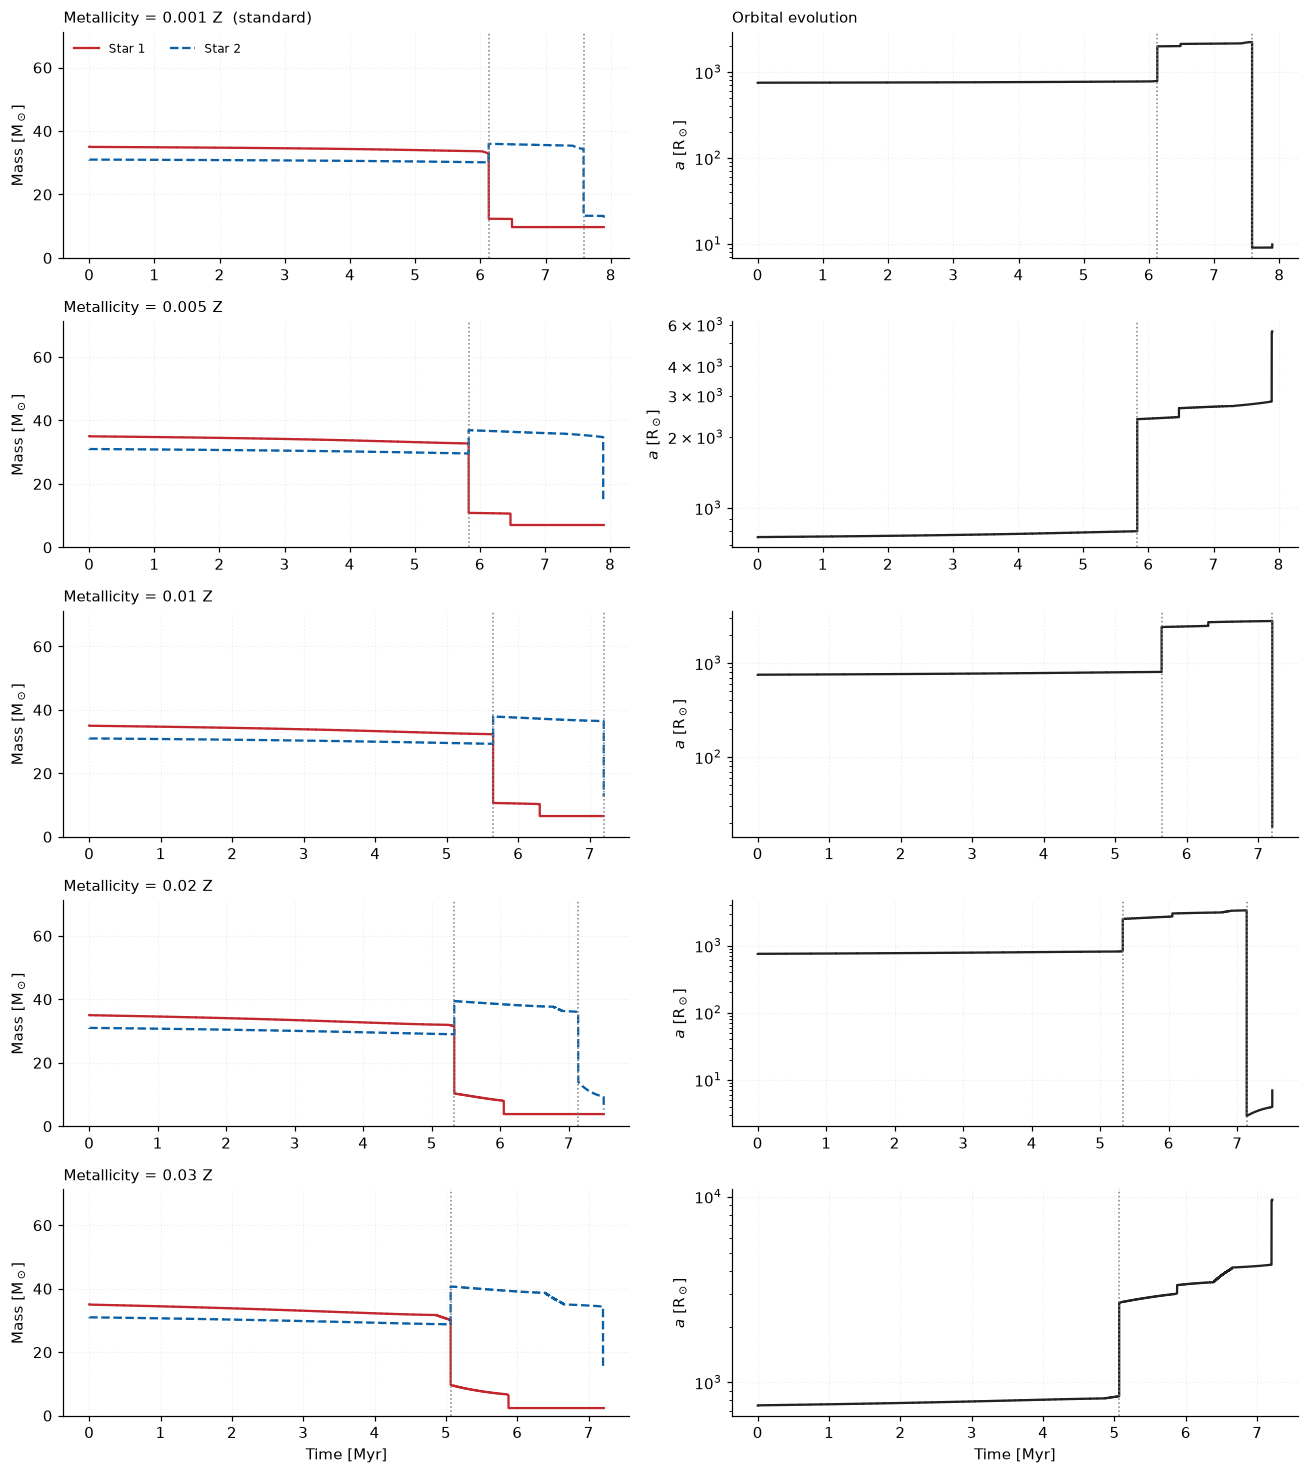

In [23]:
def run_label(run, varied_parameter):
    label, unit = PARAMETER_INFO[varied_parameter]
    value = run["meta"][varied_parameter]
    return f"{label} = {value:g} {unit}" + ("  (standard)" if run["meta"]["is_standard"] else "")


def interaction_times(df):
    if "MT_History" not in df: return []
    mt = df["MT_History"].to_numpy(dtype=int)
    return list(df["Time"].iloc[episode_starts(mt)])


def plot_mass_and_orbit(runs, varied_parameter):
    fig, axes = plt.subplots(len(runs), 2, figsize=(12, 2.7*len(runs)), squeeze=False)
    mass_max = max((r["df"]["Mass(1)"] + r["df"]["Mass(2)"]).max() for r in runs)*1.08
    for row, run in enumerate(runs):
        df = run["df"]
        axm, axa = axes[row]
        axm.plot(df.Time, df["Mass(1)"], color=C1, label="Star 1")
        axm.plot(df.Time, df["Mass(2)"], color=C2, ls="--", label="Star 2")
        axm.set_ylim(0, mass_max); axm.set_ylabel(r"Mass [M$_\odot$]")
        axm.set_title(run_label(run, varied_parameter), loc="left", fontsize=10)
        axa.plot(df.Time, df.SemiMajorAxis, color=CSYS)
        axa.set_yscale("log"); axa.set_ylabel(r"$a$ [R$_\odot$]")
        for ax in (axm, axa):
            for t in interaction_times(df): ax.axvline(t, color="grey", ls=":", lw=1)
        if row == 0: axm.legend(ncol=2, fontsize=8); axa.set_title("Orbital evolution", loc="left", fontsize=10)
    axes[-1,0].set_xlabel("Time [Myr]"); axes[-1,1].set_xlabel("Time [Myr]")
    plt.tight_layout(); plt.show()

plot_mass_and_orbit(runs, VARIED_PARAMETER)

## 7. Roche-lobe filling

The ratio (R/R_{
m L}=1) marks Roche-lobe filling. Values above one identify overflow in the recorded detailed output.

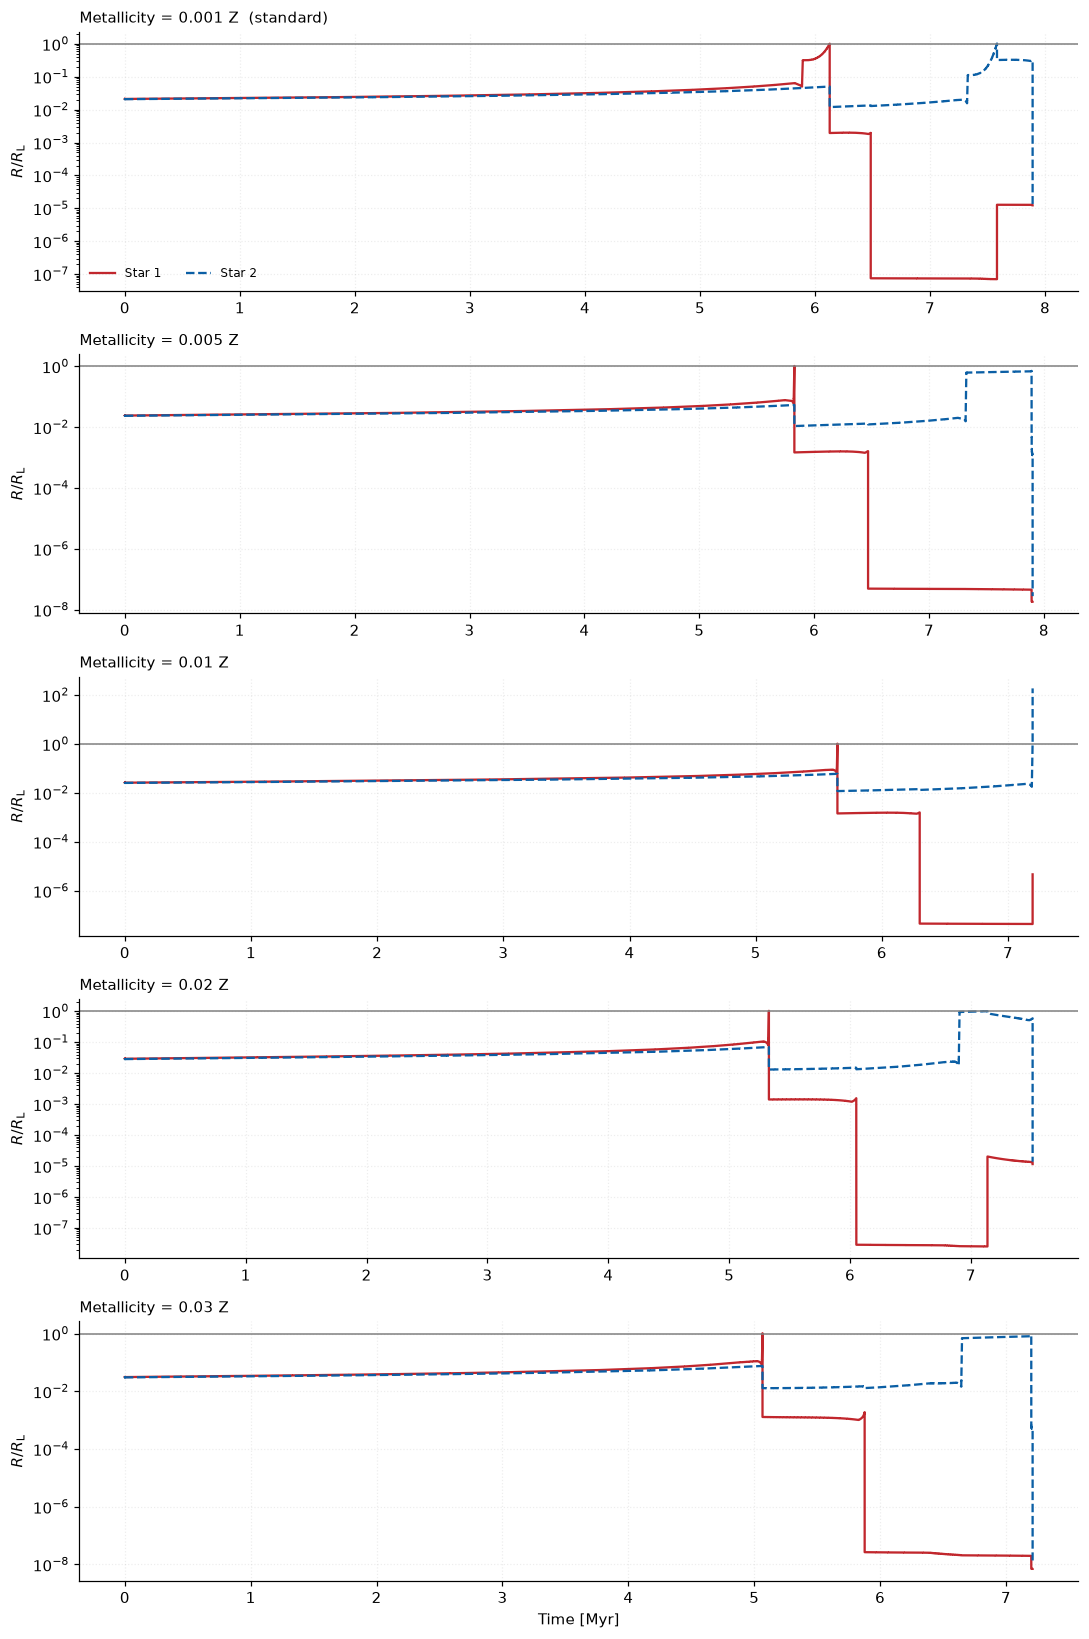

In [24]:
def plot_roche_lobe_filling(runs, varied_parameter):
    fig, axes = plt.subplots(len(runs), 1, figsize=(10, 3*len(runs)), sharex=False, squeeze=False)
    for row, run in enumerate(runs):
        df, ax = run["df"], axes[row,0]
        for star, color, ls in [(1,C1,"-"),(2,C2,"--")]:
            ratio = df[f"Radius({star})"] / df[f"RocheLobe({star})"].replace(0, np.nan)
            ax.plot(df.Time, ratio, color=color, ls=ls, label=f"Star {star}")
        ax.axhline(1, color="grey", lw=1)
        ax.set_yscale("log"); ax.set_ylabel(r"$R/R_{\rm L}$")
        ax.set_title(run_label(run, varied_parameter), loc="left", fontsize=10)
        if row == 0: ax.legend(ncol=2, fontsize=8)
    axes[-1,0].set_xlabel("Time [Myr]")
    plt.tight_layout(); plt.show()

plot_roche_lobe_filling(runs, VARIED_PARAMETER)

## 8. Luminosity and effective temperature

Compact remnants are excluded because stellar luminosity and effective temperature are not physically meaningful for them in this representation.

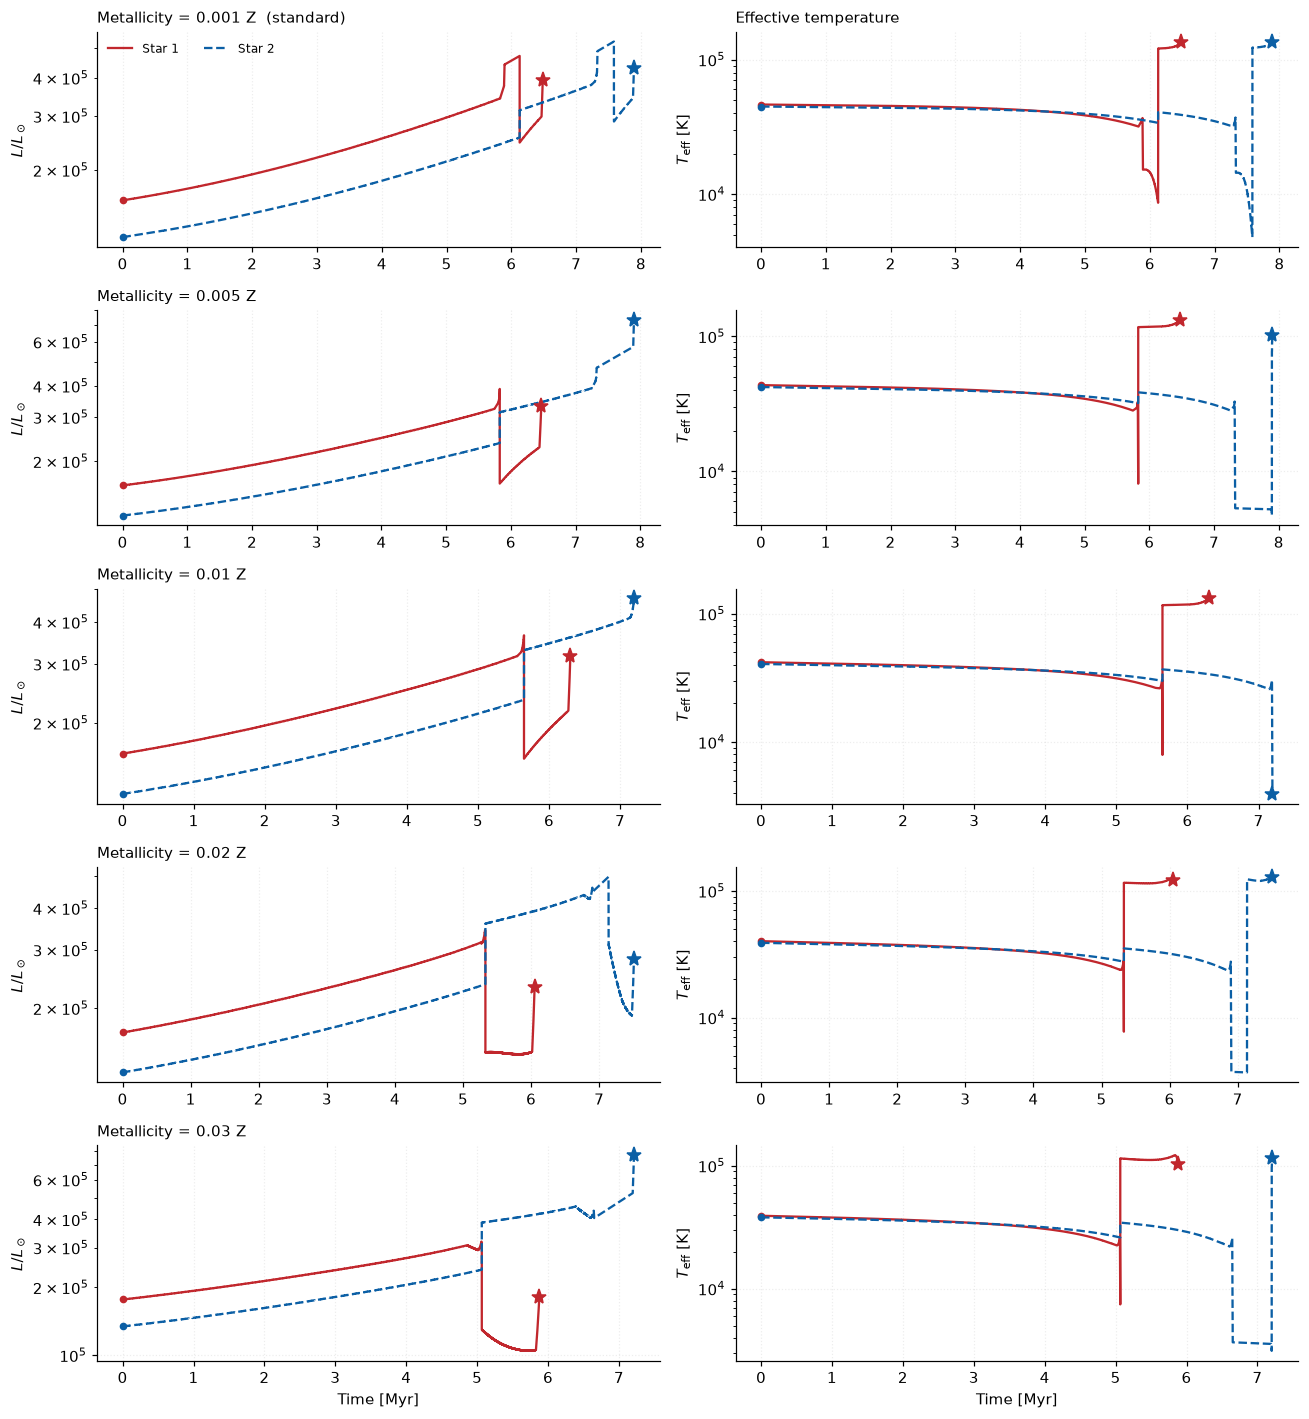

In [25]:
def plot_stellar_properties(runs, varied_parameter):
    fig, axes = plt.subplots(len(runs), 2, figsize=(12, 2.6*len(runs)), squeeze=False)
    for row, run in enumerate(runs):
        df = run["df"]
        for star, color, ls in [(1,C1,"-"),(2,C2,"--")]:
            mask = df[f"Stellar_Type({star})"] <= 9
            stellar = df.loc[mask]
            for ax, quantity in [(axes[row,0], f"Luminosity({star})"),
                                 (axes[row,1], f"Teff({star})")]:
                valid = stellar[["Time", quantity]].replace([np.inf, -np.inf], np.nan).dropna()
                valid = valid[valid[quantity] > 0]  # Both panels have logarithmic y-axes.
                if valid.empty:
                    continue
                ax.plot(valid["Time"], valid[quantity], color=color, ls=ls, label=f"Star {star}")
                ax.plot(valid["Time"].iloc[0], valid[quantity].iloc[0],
                        marker="o", color=color, ms=4, ls="none", zorder=4)
                ax.plot(valid["Time"].iloc[-1], valid[quantity].iloc[-1],
                        marker="*", color=color, ms=10, ls="none", zorder=5)
        axes[row,0].set_yscale("log"); axes[row,0].set_ylabel(r"$L/L_\odot$")
        axes[row,1].set_yscale("log"); axes[row,1].set_ylabel(r"$T_{\rm eff}$ [K]")
        axes[row,0].set_title(run_label(run, varied_parameter), loc="left", fontsize=10)
        if row == 0: axes[row,0].legend(ncol=2, fontsize=8); axes[row,1].set_title("Effective temperature", loc="left", fontsize=10)
    axes[-1,0].set_xlabel("Time [Myr]"); axes[-1,1].set_xlabel("Time [Myr]")
    plt.tight_layout(); plt.show()

plot_stellar_properties(runs, VARIED_PARAMETER)

## 9. HR diagrams

One panel per run avoids the confusion of overlaying twelve evolutionary tracks. Circles mark ZAMS and stars mark the last recorded point before compact-object formation or termination.

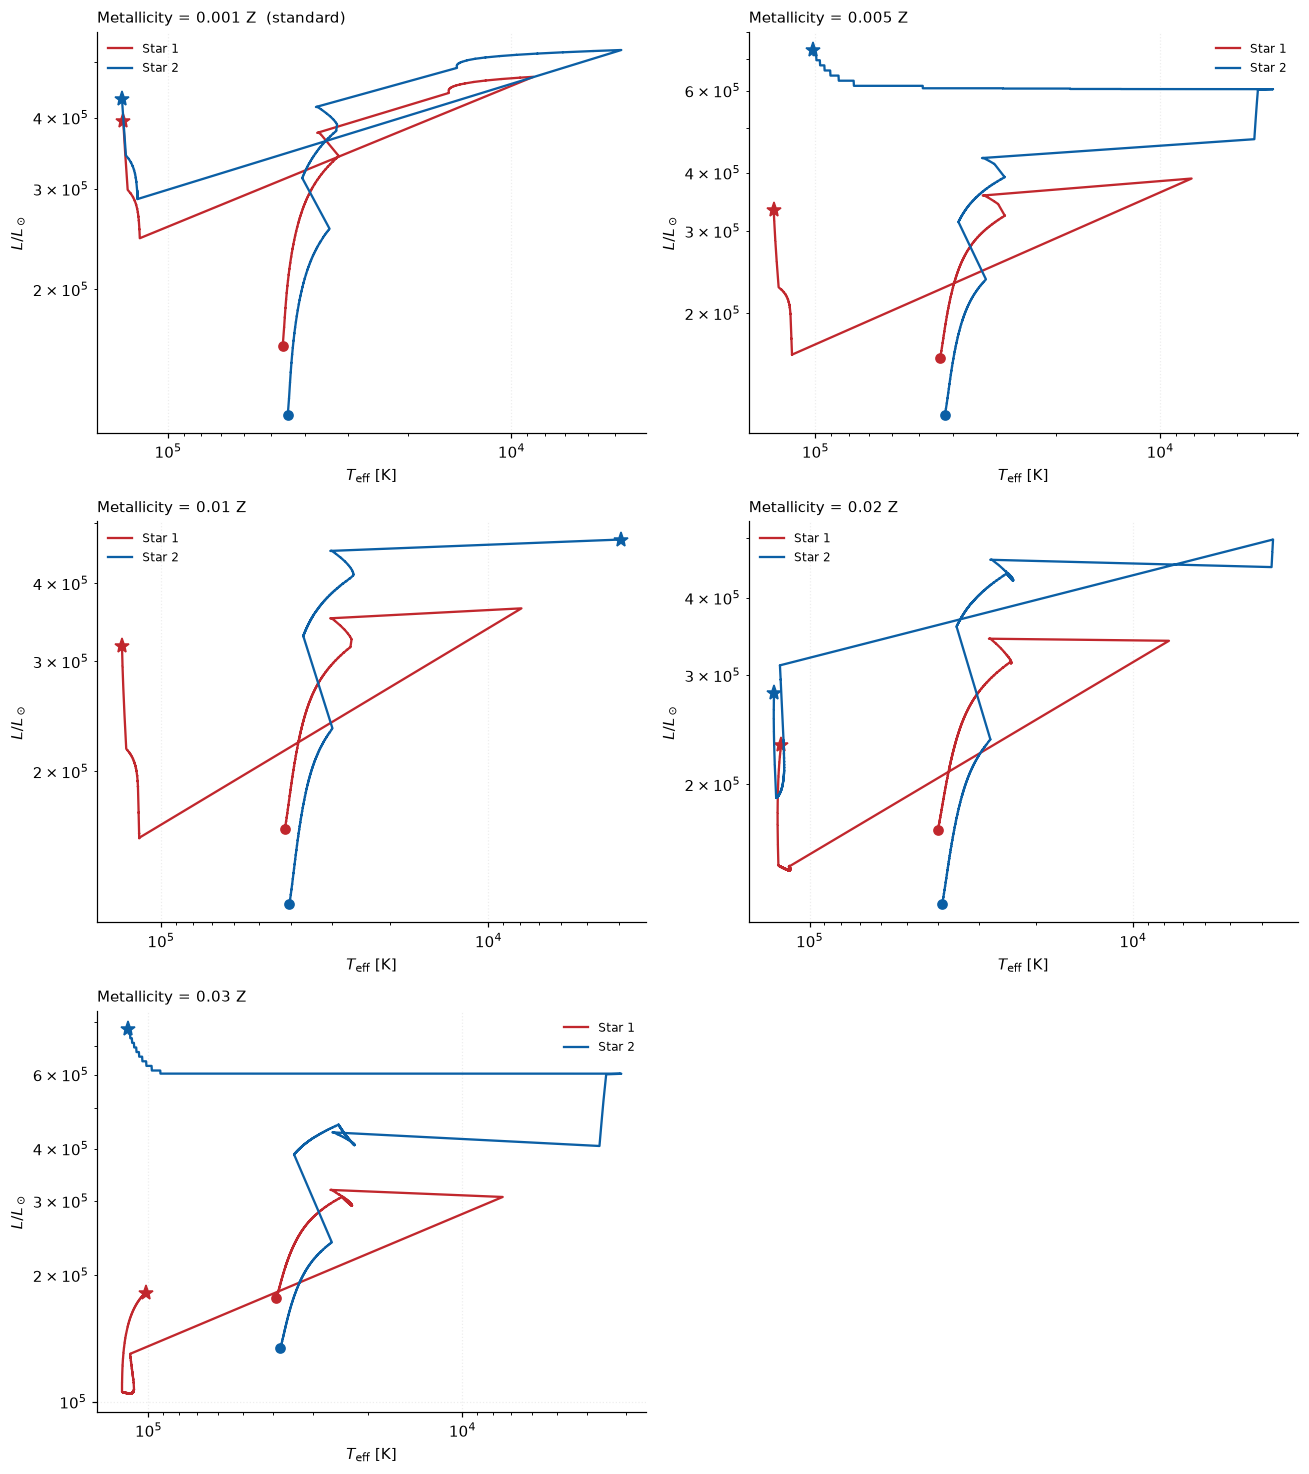

In [26]:
def plot_hr_diagrams(runs, varied_parameter, ncols=2):
    nrows = int(np.ceil(len(runs)/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4.5*nrows), squeeze=False)
    for ax, run in zip(axes.flat, runs):
        df = run["df"]
        for star, color in [(1,C1),(2,C2)]:
            d = df[df[f"Stellar_Type({star})"] <= 9]
            if d.empty: continue
            ax.plot(d[f"Teff({star})"], d[f"Luminosity({star})"], color=color, label=f"Star {star}")
            ax.plot(d[f"Teff({star})"].iloc[0], d[f"Luminosity({star})"].iloc[0], "o", color=color)
            ax.plot(d[f"Teff({star})"].iloc[-1], d[f"Luminosity({star})"].iloc[-1], "*", color=color, ms=10)
        ax.set_xscale("log"); ax.set_yscale("log"); ax.invert_xaxis()
        ax.set_xlabel(r"$T_{\rm eff}$ [K]"); ax.set_ylabel(r"$L/L_\odot$")
        ax.set_title(run_label(run, varied_parameter), loc="left", fontsize=10); ax.legend(fontsize=8)
    for ax in axes.flat[len(runs):]: ax.remove()
    plt.tight_layout(); plt.show()

plot_hr_diagrams(runs, VARIED_PARAMETER)

## 10. Event timelines and detailed event tables

The timeline provides a quick comparison of when interactions and stellar-type transitions occur. The tables below it retain the full text.

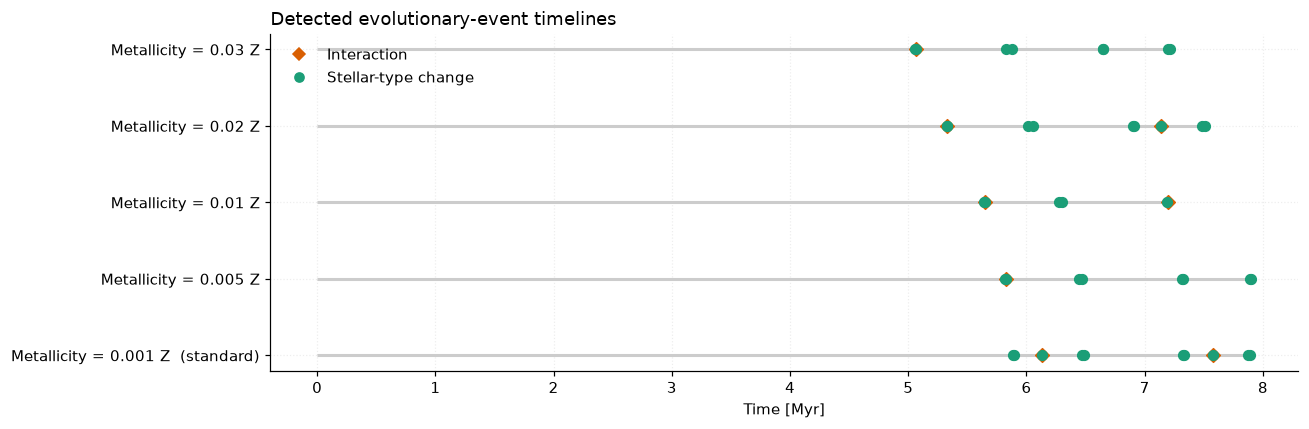


Metallicity = 0.001 Z  (standard)


,time_myr,category,event
0,5.8866,stellar type,Star 1: Main sequence → Hertzsprung gap
1,5.8937,stellar type,Star 1: Hertzsprung gap → Core helium burning
2,6.1276,stellar type,Star 1: Core helium burning → Naked helium sta...
3,6.1276,interaction,Stable MT 1→2
4,6.4655,stellar type,Star 1: Naked helium star MS → Naked helium st...
5,6.4844,stellar type,Star 1: Naked helium star HG → Black hole
6,7.3217,stellar type,Star 2: Main sequence → Hertzsprung gap
7,7.3283,stellar type,Star 2: Hertzsprung gap → Core helium burning
8,7.5820,stellar type,Star 2: Core helium burning → Naked helium sta...
9,7.5820,interaction,CE 2→1 (survived)



Metallicity = 0.005 Z


,time_myr,category,event
0,5.8216,stellar type,Star 1: Main sequence → Hertzsprung gap
1,5.8278,stellar type,Star 1: Hertzsprung gap → Naked helium star MS
2,5.8278,interaction,Stable MT 1→2
3,6.4419,stellar type,Star 1: Naked helium star MS → Naked helium st...
4,6.4694,stellar type,Star 1: Naked helium star HG → Black hole
5,7.3182,stellar type,Star 2: Main sequence → Hertzsprung gap
6,7.3248,stellar type,Star 2: Hertzsprung gap → Core helium burning
7,7.8901,stellar type,Star 2: Core helium burning → Early AGB
8,7.9017,stellar type,Star 2: Early AGB → Black hole



Metallicity = 0.01 Z


,time_myr,category,event
0,5.6430,stellar type,Star 1: Main sequence → Hertzsprung gap
1,5.6479,stellar type,Star 1: Hertzsprung gap → Naked helium star MS
2,5.6479,interaction,Stable MT 1→2
3,6.2723,stellar type,Star 1: Naked helium star MS → Naked helium st...
4,6.3002,stellar type,Star 1: Naked helium star HG → Black hole
5,7.1887,stellar type,Star 2: Main sequence → Hertzsprung gap
6,7.1951,interaction,Merger



Metallicity = 0.02 Z


,time_myr,category,event
0,5.3239,stellar type,Star 1: Main sequence → Hertzsprung gap
1,5.3286,stellar type,Star 1: Hertzsprung gap → Naked helium star MS
2,5.3286,interaction,Stable MT 1→2
3,6.0155,stellar type,Star 1: Naked helium star MS → Naked helium st...
4,6.0515,stellar type,Star 1: Naked helium star HG → Black hole
5,6.8992,stellar type,Star 2: Main sequence → Hertzsprung gap
6,6.9055,stellar type,Star 2: Hertzsprung gap → Core helium burning
7,7.1371,stellar type,Star 2: Core helium burning → Naked helium sta...
8,7.1371,interaction,CE 2→1 (survived)
9,7.4809,stellar type,Star 2: Naked helium star MS → Naked helium st...



Metallicity = 0.03 Z


,time_myr,category,event
0,5.0609,stellar type,Star 1: Main sequence → Hertzsprung gap
1,5.0657,stellar type,Star 1: Hertzsprung gap → Naked helium star MS
2,5.0657,interaction,Stable MT 1→2
3,5.8295,stellar type,Star 1: Naked helium star MS → Naked helium st...
4,5.8772,stellar type,Star 1: Naked helium star HG → Neutron star
5,6.6446,stellar type,Star 2: Main sequence → Hertzsprung gap
6,6.6509,stellar type,Star 2: Hertzsprung gap → Core helium burning
7,7.1940,stellar type,Star 2: Core helium burning → Early AGB
8,7.2116,stellar type,Star 2: Early AGB → Black hole


In [27]:
def plot_event_timelines(runs, varied_parameter):
    fig, ax = plt.subplots(figsize=(12, max(4, .8*len(runs))))
    colors = {"interaction":"#D95F02", "stellar type":"#1B9E77", "disruption":"#7570B3"}
    for y, run in enumerate(runs):
        df, ev = run["df"], find_events(run["df"])
        ax.hlines(y, 0, df.Time.iloc[-1], color="0.8", lw=2)
        for category, group in ev.groupby("category"):
            ax.scatter(group.time_myr, np.full(len(group),y), color=colors.get(category,"black"),
                       marker="D" if category=="interaction" else "o", s=40, zorder=3)
    ax.set_yticks(range(len(runs)), [run_label(r,varied_parameter) for r in runs])
    ax.set_xlabel("Time [Myr]"); ax.set_title("Detected evolutionary-event timelines", loc="left")
    ax.legend(handles=[Line2D([],[],marker="D",ls="none",color=colors["interaction"],label="Interaction"),
                       Line2D([],[],marker="o",ls="none",color=colors["stellar type"],label="Stellar-type change")])
    plt.tight_layout(); plt.show()

plot_event_timelines(runs, VARIED_PARAMETER)

for run in runs:
    print("\n" + run_label(run, VARIED_PARAMETER))
    display(find_events(run["df"]).round({"time_myr":4}))

## 11. Optional: compare evolution relative to the first interaction

Absolute ages are physically meaningful, but aligning runs at their first interaction helps compare what happens *after* interaction begins. Non-interacting runs are omitted.

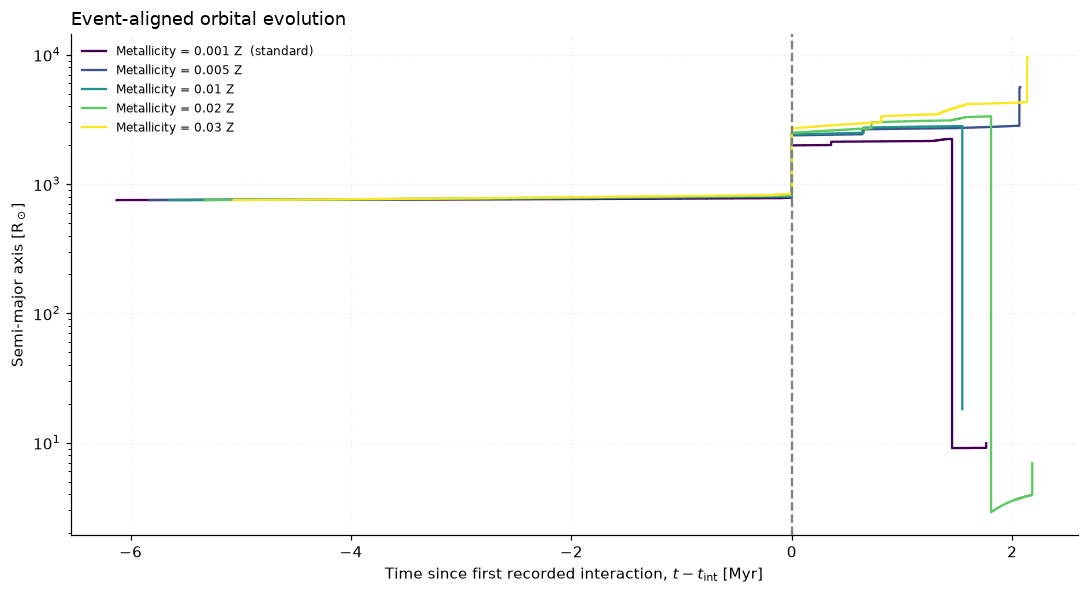

In [28]:
def plot_event_aligned_separation(runs, varied_parameter):
    fig, ax = plt.subplots(figsize=(10,5.5))
    plotted = 0
    cmap = plt.get_cmap("viridis")
    for i, run in enumerate(runs):
        df = run["df"]
        if "MT_History" not in df: continue
        interacting = df["MT_History"].to_numpy(dtype=int) != 0
        t0 = first_true_time(df, interacting)
        if not np.isfinite(t0): continue
        ax.plot(df.Time-t0, df.SemiMajorAxis, color=cmap(i/max(1,len(runs)-1)),
                label=run_label(run,varied_parameter))
        plotted += 1
    if plotted:
        ax.axvline(0,color="grey",ls="--"); ax.set_yscale("log")
        ax.set_xlabel(r"Time since first recorded interaction, $t-t_{\rm int}$ [Myr]")
        ax.set_ylabel(r"Semi-major axis [R$_\odot$]"); ax.legend(fontsize=8)
        ax.set_title("Event-aligned orbital evolution", loc="left"); plt.tight_layout(); plt.show()
    else:
        plt.close(fig); print("No recorded interactions were found.")

plot_event_aligned_separation(runs, VARIED_PARAMETER)

## Reusing this notebook

1. Keep the standard file outside the experiment folders.
2. Put all alternative runs for one experiment into a single folder.
3. Change `EXPERIMENT_FOLDER` and `VARIED_PARAMETER` in the configuration cell.
4. Run all cells.
5. Inspect the validation table before interpreting the plots.

For physics-prescription experiments (for example common-envelope efficiency or kick prescription), the varied value may not be stored in the detailed-output file. In that case the loader will need a small metadata table mapping filenames to prescription values; the remaining analysis functions can stay unchanged.